### SweebApp - Model for phishing detection 🤖

In the next phase of the project, two different machine learning approaches will be implemented and evaluated in order to solve the URL phishing detection problem.

# 1. Classical Machine Learning Model (Tabular Data)

The first approach consists of building a classification model using **scikit-learn's RandomForestClassifier**, trained on the structured dataset created during the preprocessing phase.
This dataset contains engineered numerical features extracted from URLs, such as:

* URL length
* number of dots and slashes
* domain characteristics
* presence of suspicious patterns

The Random Forest model was chosen due to its robustness, ability to handle tabular data efficiently, and strong performance without requiring feature normalization.

# 2. 

# 1. Classical Machine Learning Model (Tabular Data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [145]:
sweeb_tubular_dataset = pd.read_csv("./sweeb_phishing_dataset.csv")

In [146]:
sweeb_tubular_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   0                        0 non-null      float64
 1   suspicious_char_path     40000 non-null  float64
 2   len_path                 40000 non-null  float64
 3   top_tld                  40000 non-null  float64
 4   suspicious_word_domain   40000 non-null  float64
 5   num_special_char_domain  40000 non-null  float64
 6   https_protocol           40000 non-null  float64
 7   num_slash                40000 non-null  float64
 8   num_dots                 40000 non-null  float64
 9   url_length               40000 non-null  float64
 10  is_threat_threat         40000 non-null  bool   
dtypes: bool(1), float64(10)
memory usage: 3.1 MB


In [147]:
sweeb_tubular_dataset.head(10)

,0,suspicious_char_path,len_path,top_tld,suspicious_word_domain,num_special_char_domain,https_protocol,num_slash,num_dots,url_length,is_threat_threat
0,NaN,0.0,25.0,0.0,0.0,0.0,0.0,1.0,2.0,25.0,False
1,NaN,0.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,23.0,True
2,NaN,0.0,54.0,0.0,0.0,0.0,0.0,2.0,2.0,54.0,False
3,NaN,0.0,35.0,0.0,0.0,0.0,0.0,1.0,1.0,35.0,True
4,NaN,0.0,22.0,0.0,0.0,0.0,0.0,1.0,1.0,22.0,True
5,NaN,0.0,21.0,0.0,0.0,0.0,0.0,1.0,1.0,21.0,True
6,NaN,0.0,10.0,0.0,0.0,0.0,0.0,3.0,4.0,132.0,True
7,NaN,0.0,56.0,0.0,0.0,0.0,0.0,4.0,1.0,56.0,False
8,NaN,0.0,33.0,0.0,0.0,0.0,0.0,2.0,2.0,33.0,False
9,NaN,0.0,25.0,0.0,0.0,0.0,0.0,2.0,2.0,25.0,False


In [148]:
sweeb_tubular_dataset = sweeb_tubular_dataset.drop('num_special_char_domain', axis=1)

In [149]:
sweeb_tubular_dataset.head(1)

,0,suspicious_char_path,len_path,top_tld,suspicious_word_domain,https_protocol,num_slash,num_dots,url_length,is_threat_threat
0,NaN,0.0,25.0,0.0,0.0,0.0,1.0,2.0,25.0,False


In [150]:
# Create X (features)
X = sweeb_tubular_dataset.drop('is_threat_threat', axis=1)

# Create y (labels)
y = sweeb_tubular_dataset['is_threat_threat']

X.head(10)

,0,suspicious_char_path,len_path,top_tld,suspicious_word_domain,https_protocol,num_slash,num_dots,url_length
0,NaN,0.0,25.0,0.0,0.0,0.0,1.0,2.0,25.0
1,NaN,0.0,23.0,0.0,0.0,0.0,1.0,1.0,23.0
2,NaN,0.0,54.0,0.0,0.0,0.0,2.0,2.0,54.0
3,NaN,0.0,35.0,0.0,0.0,0.0,1.0,1.0,35.0
4,NaN,0.0,22.0,0.0,0.0,0.0,1.0,1.0,22.0
5,NaN,0.0,21.0,0.0,0.0,0.0,1.0,1.0,21.0
6,NaN,0.0,10.0,0.0,0.0,0.0,3.0,4.0,132.0
7,NaN,0.0,56.0,0.0,0.0,0.0,4.0,1.0,56.0
8,NaN,0.0,33.0,0.0,0.0,0.0,2.0,2.0,33.0
9,NaN,0.0,25.0,0.0,0.0,0.0,2.0,2.0,25.0


In [151]:
y.head(10)

0    False
1     True
2    False
3     True
4     True
5     True
6     True
7    False
8    False
9    False
Name: is_threat_threat, dtype: bool

In [152]:
# Model
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [153]:
# Setup random seed
np.random.seed(42)

In [155]:
# Fit the model to the training data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

len(X_train), len(y_train), len(X_test), len(y_test)

(32000, 32000, 8000, 8000)

In [156]:
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [157]:
y_pred = clf.predict(X_test)

In [158]:
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score , ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.62      0.68      0.65      3891
        True       0.67      0.60      0.63      4109

    accuracy                           0.64      8000
   macro avg       0.64      0.64      0.64      8000
weighted avg       0.64      0.64      0.64      8000



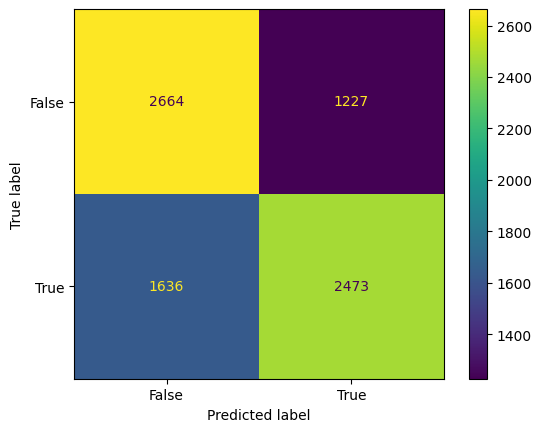

In [159]:
cm = confusion_matrix(y_test,y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

# 2. NLP-Based Model (Transformer – URLBERT)

In [2]:
# Imports
import torch
import os
from datasets import load_dataset,Dataset
from peft import get_peft_model, LoraConfig
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer,pipeline

In [3]:
!nvidia-smi

Sun May 17 10:32:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   35C    P3              7W /  180W |    1633MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [98]:
model_name = "CrabInHoney/urlbert-tiny-v4-phishing-classifier"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/137 [00:00<?, ?it/s]

In [99]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(400, 192, padding_idx=0)
      (position_embeddings): Embedding(64, 192)
      (token_type_embeddings): Embedding(2, 192)
      (LayerNorm): LayerNorm((192,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-7): 8 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=192, out_features=192, bias=True)
              (key): Linear(in_features=192, out_features=192, bias=True)
              (value): Linear(in_features=192, out_features=192, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=192, out_features=192, bias=True)
              (LayerNorm): LayerNorm((192,), eps=1e-12, elem

In [139]:
print(model.get_memory_footprint()/1e6)

14.745864


In [10]:
for param in model.base_model.encoder.layer[-2].parameters():
    param.require_grad = True

In [6]:
dataset_path = "C:\\Users\\CprAlin\\Documents\\datasets\\sweeb_phishing_nlp_dataset.csv"

In [73]:
sweeb_nlp_dataset = pd.read_csv(dataset_path)

In [74]:
sweeb_nlp_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1206783 entries, 0 to 1206782
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   url        1206783 non-null  str  
 1   is_threat  1206783 non-null  int64
dtypes: int64(1), str(1)
memory usage: 82.6 MB


In [15]:
sweeb_nlp_dataset.head(10)

,url,is_threat
0,https://portal.example.org/test.php?id=122106,1
1,https://internal.bank.local/manager/html?id=66...,0
2,https://api.service.io/shell?id=93764,0
3,https://api.service.io/wp-login.php?id=806545,0
4,https://api.service.io/.env?id=61251,0
5,https://api.service.io/?id=101406,0
6,https://api.service.io/owa/auth/logon.aspx?id=...,0
7,https://api.service.io/phpmyadmin?id=935208,0
8,https://internal.bank.local/api/v1/users?id=59...,0
9,https://internal.bank.local/api/v1/users?id=88...,0


In [13]:
sweeb_nlp_dataset["is_threat"].value_counts()

is_threat
1    772690
0    434093
Name: count, dtype: int64

In [39]:
dataset = load_dataset("csv", data_files=dataset_path)

dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'is_threat'],
        num_rows: 1206783
    })
})

In [20]:
test_url = dataset["train"]["url"][0]

In [15]:
label_mapping = {"LABEL_0": "good", "LABEL_1": "fish"}

In [19]:
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True
)

In [22]:
result = classifier(test_url)
print(f"Url : {test_url}")

result

Url : https://portal.example.org/test.php?id=122106


[{'label': 'LABEL_0', 'score': 0.9988943934440613}]

In [25]:
result[0]['label']

'LABEL_0'

In [26]:
label = result[0]['label']
score = result[0]['score']
friendly_label = label_mapping.get(label,label)
print(f"Label : {friendly_label} \n Score : {score}")

Label : good 
 Score : 0.9988943934440613


In [17]:
input = tokenizer(url, truncation=True, max_length=512,padding="max_length")

In [18]:
input

{'input_ids': [2, 6, 10, 8, 8, 256, 97, 116, 76, 9, 221, 9, 364, 103, 8, 49, 100, 87, 81, 90, 8, 214, 76, 12, 53, 84, 1, 32, 22, 19, 19, 18, 23, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [40]:
def tokenize(batch):
  return tokenizer(
      batch["url"],
      truncation=True,
      max_length=64,
      padding="max_length"
  )

In [20]:
print(type(dataset["train"][0]["url"]))

<class 'str'>


In [41]:
dataset = dataset.rename_column("is_threat","label")

In [42]:
dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'label'],
        num_rows: 1206783
    })
})

In [43]:
dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'label'],
        num_rows: 1206783
    })
})

In [44]:
dataset = dataset.map(tokenize, batched=True, remove_columns=['url'])

In [45]:
import random

In [46]:
threat_dataset = [x for x in dataset['train'] if x['label'] == 1]
nonthreat_dataset = [x for x in dataset['train'] if x['label'] == 0]

threat_dataset = random.sample(threat_dataset, len(nonthreat_dataset))

balanced_dataset = threat_dataset + nonthreat_dataset

In [47]:
len(threat_dataset) , len(nonthreat_dataset) , len(balanced_dataset)

(434093, 434093, 868186)

In [48]:
dataset = Dataset.from_list(balanced_dataset)
dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 868186
})

In [121]:
small_train = dataset.shuffle(seed=42).select(range(40000))
small_test = dataset.shuffle(seed=42).select(range(7000))

In [101]:
small_train

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30000
})

In [102]:
small_test

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6000
})

In [143]:
threat_urls = 0
non_threat_url = 0
for url in small_train:
    if url['label'] == 1:
        threat_urls += 1
    else:
        non_threat_url += 1

print(f'Threat URL`s : {threat_urls} \n Non threat URL`s : {non_threat_url}')

Threat URL`s : 9927 
 Non threat URL`s : 10073


In [115]:
threat_urls = 0
non_threat_url = 0
for url in small_test:
    if url['label'] == 1:
        threat_urls += 1
    else:
        non_threat_url += 1

print(f'Threat URL`s : {threat_urls} \n Non threat URL`s : {non_threat_url}')

Threat URL`s : 1486 
 Non threat URL`s : 1514


In [103]:
from scipy.special import softmax

In [115]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  #preds = logits.argmax(axis=1)
  probs = softmax(logits, axis=1)

  threshold = 0.35
  preds = (probs[:,1] > threshold).astype(int)

  precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

  acc = accuracy_score(labels, preds)

  return {
      "accuracy" : acc,
      "f1" : f1,
      "precision" : precision,
      "recall" : recall
  }

In [122]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=1e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

In [123]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics
)

In [107]:
import datetime as dt
time = dt.datetime.now()

In [108]:
print(time.strftime("%Y-%m-%d %H:%M"))
trainer.train()
print(time.strftime("%Y-%m-%d %H:%M"))


2026-05-17 18:48


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.597819,0.511512,0.723167,0.670371,0.811239,0.571187
2,0.526908,0.494956,0.649000,0.691925,0.609693,0.799797
3,0.517214,0.481718,0.728167,0.691624,0.784305,0.618532
4,0.504379,0.466544,0.753000,0.702290,0.864918,0.591140
5,0.494443,0.457550,0.642833,0.710366,0.591625,0.888739
6,0.485486,0.436457,0.743167,0.733897,0.749824,0.718634
7,0.471001,0.421656,0.740000,0.746589,0.718349,0.777139
8,0.458221,0.410162,0.774000,0.760170,0.796811,0.726750
9,0.435364,0.385350,0.761167,0.779029,0.715986,0.854244
10,0.420585,0.362510,0.779833,0.793626,0.737515,0.858979


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-17 18:48


In [124]:
print(time.strftime("%Y-%m-%d %H:%M"))
trainer.train(resume_from_checkpoint=True)
print(time.strftime("%Y-%m-%d %H:%M"))

2026-05-17 18:48


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
16,0.401176,0.295287,0.868857,0.868179,0.855889,0.880828
17,0.386178,0.287921,0.878571,0.871212,0.907513,0.837704
18,0.381377,0.274114,0.879143,0.878553,0.865874,0.891608
19,0.364909,0.249242,0.878857,0.882938,0.838930,0.931818
20,0.354983,0.235673,0.900714,0.899377,0.893813,0.905012
21,0.335386,0.213760,0.893714,0.896753,0.856121,0.941434
22,0.318772,0.207048,0.913286,0.912067,0.906943,0.917249
23,0.312837,0.192319,0.908143,0.909500,0.879662,0.941434
24,0.303119,0.188479,0.910286,0.911499,0.882642,0.942308
25,0.290940,0.184531,0.914571,0.915465,0.889072,0.943473


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-17 18:48


In [125]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.290940,0.184531,25,0.914571,0.915465,0.889072,0.943473


{'eval_loss': 0.18453055620193481,
 'eval_accuracy': 0.9145714285714286,
 'eval_f1': 0.9154650834040147,
 'eval_precision': 0.8890719384953323,
 'eval_recall': 0.9434731934731935}

In [ ]:
trainer.save_model("sweeb_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [127]:
tokenizer.save_pretrained("sweeb_model")

('sweeb_model\\tokenizer_config.json', 'sweeb_model\\tokenizer.json')

In [131]:
sweeb_model_path = "sweeb_model"

sweeb_model = AutoModelForSequenceClassification.from_pretrained(sweeb_model_path)
sweeb_tokenizer = AutoTokenizer.from_pretrained(sweeb_model_path)

Loading weights:   0%|          | 0/137 [00:00<?, ?it/s]

In [132]:
sweeb_model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(400, 192, padding_idx=0)
      (position_embeddings): Embedding(64, 192)
      (token_type_embeddings): Embedding(2, 192)
      (LayerNorm): LayerNorm((192,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-7): 8 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=192, out_features=192, bias=True)
              (key): Linear(in_features=192, out_features=192, bias=True)
              (value): Linear(in_features=192, out_features=192, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=192, out_features=192, bias=True)
              (LayerNorm): LayerNorm((192,), eps=1e-12, elem

In [133]:
def predict_sweeb(url):

    sweeb_classifier = pipeline(
        "text-classification",
        model=sweeb_model,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True
    )

    label_mapping = {"LABEL_0" : "safe", "LABEL_1" : "threat"}
    result = sweeb_classifier(url)

    label = result[0]['label']
    score = result[0]['score']
    friendly_label = label_mapping.get(label,label)

    print(f"Label : {friendly_label} \n Score : {score}")

In [135]:
sweeb_dataset = pd.read_csv(dataset_path)

In [142]:
test_url = sweeb_dataset["url"][45000]

In [143]:
predict_sweeb(test_url)

Label : threat 
 Score : 0.9969372749328613
